# Unsupervised Cluster Visualization (ACME)

End-to-end demo of the clustering-first detector:

1. Load ACME process telemetry.
2. Use `TelemetryClusterDetector` to build **unsupervised** session clusters (no labels used for fitting/clustering).
3. Project the session embeddings to 2D with **UMAP**.
4. Render the labeled clusters with **datamapplot**, with **red-team sessions colored on top** so we can see whether suspicious activity concentrates in specific clusters.

Labels (`red_team` / `bad_user`) are used **only** for coloring/evaluation, never for clustering.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import datamapplot

from telemetry_cluster_detector import TelemetryClusterDetector, ClusterDetectorConfig
from validate_cluster_detector import stratified_test_sample

RANDOM_STATE = 42
TRAIN_N = 20_000   # bump to 50_000 to match the validation run
TEST_BENIGN_N = 10_000
TRAIN_PATH = "Data/data/ACME4/gold/train-process_uber_summary.parquet"
TEST_PATH = "Data/data/ACME4/gold/test-process_uber_summary.parquet"

## 1. Load and sample ACME telemetry

Train is fit material (treated as mostly benign); test is a stratified sample that keeps all red-team / bad-user processes plus a benign background.

In [23]:
train_raw = pd.read_parquet(TRAIN_PATH)
test_raw = pd.read_parquet(TEST_PATH)

train = (
    train_raw.sample(n=min(TRAIN_N, len(train_raw)), random_state=RANDOM_STATE)
    .drop_duplicates("pid_hash", keep="first")
    .reset_index(drop=True)
)
test = stratified_test_sample(test_raw, TEST_BENIGN_N, RANDOM_STATE)
print(f"train processes: {len(train):,}")
print(f"test processes:  {len(test):,}")

train processes: 20,000
test processes:  11,188


## 2. Run the clustering-first detector

`fit` learns session-text SVD embeddings + the anomaly scorer; `detect` sessionizes the test data (file-resource edges), scores sessions, and clusters them with MiniBatchKMeans.

In [24]:
config = ClusterDetectorConfig(random_state=RANDOM_STATE, max_clusters=64)
detector = TelemetryClusterDetector(config).fit(train)
result = detector.detect(test)

print(f"quality_ok={result.quality_ok}  n_clusters={result.n_clusters}  strategy={result.ranking_strategy}")
print(f"sessions={result.quality_report.get('n_sessions')}  max_session_fraction={result.quality_report.get('max_session_fraction'):.4f}")

triage_cols = [c for c in ["cluster_id", "cluster_label", "n_sessions", "score_p95_size_adjusted",
                            "red_team_sessions", "red_team_rate"] if c in result.cluster_triage.columns]
result.cluster_triage[triage_cols].head(15)

quality_ok=True  n_clusters=64  strategy=size_adjusted_p95
sessions=10479  max_session_fraction=0.0208


,cluster_id,cluster_label,n_sessions,score_p95_size_adjusted,red_team_sessions,red_team_rate
0,43,file/path: wintap,1101,6.488490,0,0.000000
1,41,dllhost.exe processid + processid,234,5.078394,140,0.598291
2,3,taskhostw.exe,176,4.744433,56,0.318182
3,58,wmic.exe os + caption,355,4.503609,0,0.000000
4,45,msedge.exe + --num-raster-threads 4,135,4.491664,135,1.000000
5,35,wmic.exe computersystem + get domain,328,4.048778,0,0.000000
6,5,msedge.exe + --launch-time-ticks,73,3.964492,67,0.917808
7,50,cmd.exe + user1,59,3.845027,13,0.220339
8,30,mousocoreworker.exe + -embedding,89,3.843668,45,0.505618
9,29,microsoftedgeupdate.exe ua + ua,62,3.794809,0,0.000000


## 3. UMAP projection of the session embeddings

`result.session_embeddings` is row-aligned with `result.session_scores`, so cluster ids and labels line up with each 2D point.

In [25]:
embeddings = np.asarray(result.session_embeddings, dtype=np.float32)
print(f"session embeddings: {embeddings.shape}")

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
coords = reducer.fit_transform(embeddings)

scores = result.session_scores.reset_index(drop=True)
# map each session's cluster id to its keyphrase label
label_map = dict(zip(result.cluster_summary["cluster_id"], result.cluster_summary.get("cluster_label", pd.Series(dtype=str))))

viz = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "cluster_id": scores["cluster_id"].to_numpy(),
    "red_team": scores["red_team"].to_numpy() if "red_team" in scores else 0,
    "bad_user": scores["bad_user"].to_numpy() if "bad_user" in scores else 0,
})
viz["cluster_label"] = viz["cluster_id"].map(label_map).fillna("").replace(
    {"": "Unlabeled", "unlabeled cluster": "Unlabeled"})
red_mask = viz["red_team"].to_numpy() == 1
print(f"red-team sessions: {int(viz['red_team'].sum())}  |  bad-user sessions: {int(viz['bad_user'].sum())}")
viz.head()

session embeddings: (10479, 48)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


red-team sessions: 641  |  bad-user sessions: 607


,x,y,cluster_id,red_team,bad_user,cluster_label
0,10.286377,0.582547,3,1,1,taskhostw.exe
1,12.683306,16.733257,41,1,1,dllhost.exe processid + processid
2,11.469597,-1.427598,41,1,1,dllhost.exe processid + processid
3,15.287039,14.420701,41,1,1,dllhost.exe processid + processid
4,18.874971,9.079469,63,1,1,firefox.exe


## 4. datamapplot: labeled clusters with red-team overlaid

Clusters are drawn and labeled with their auto keyphrases; red-team sessions are scattered on top in red. Note: with many small clusters the labels get crowded — section 4b is the cleaner read of the actual effect.

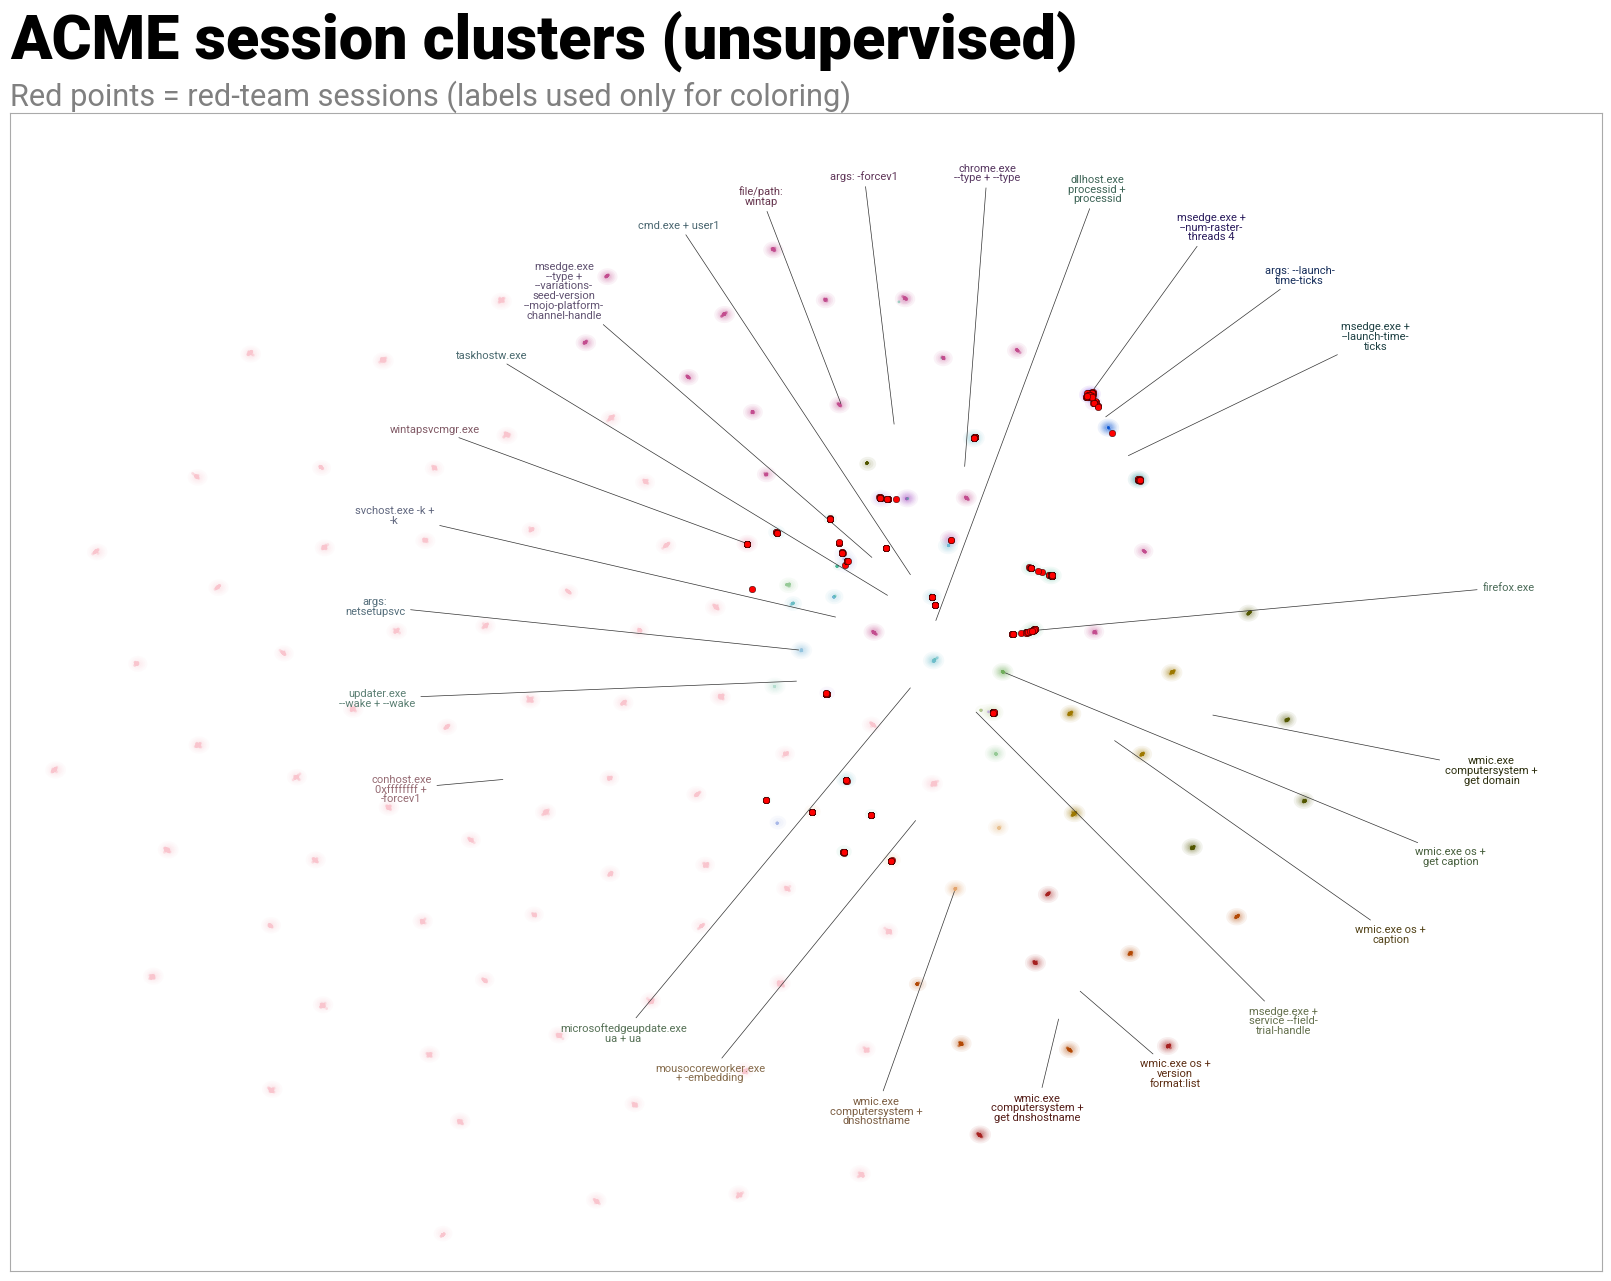

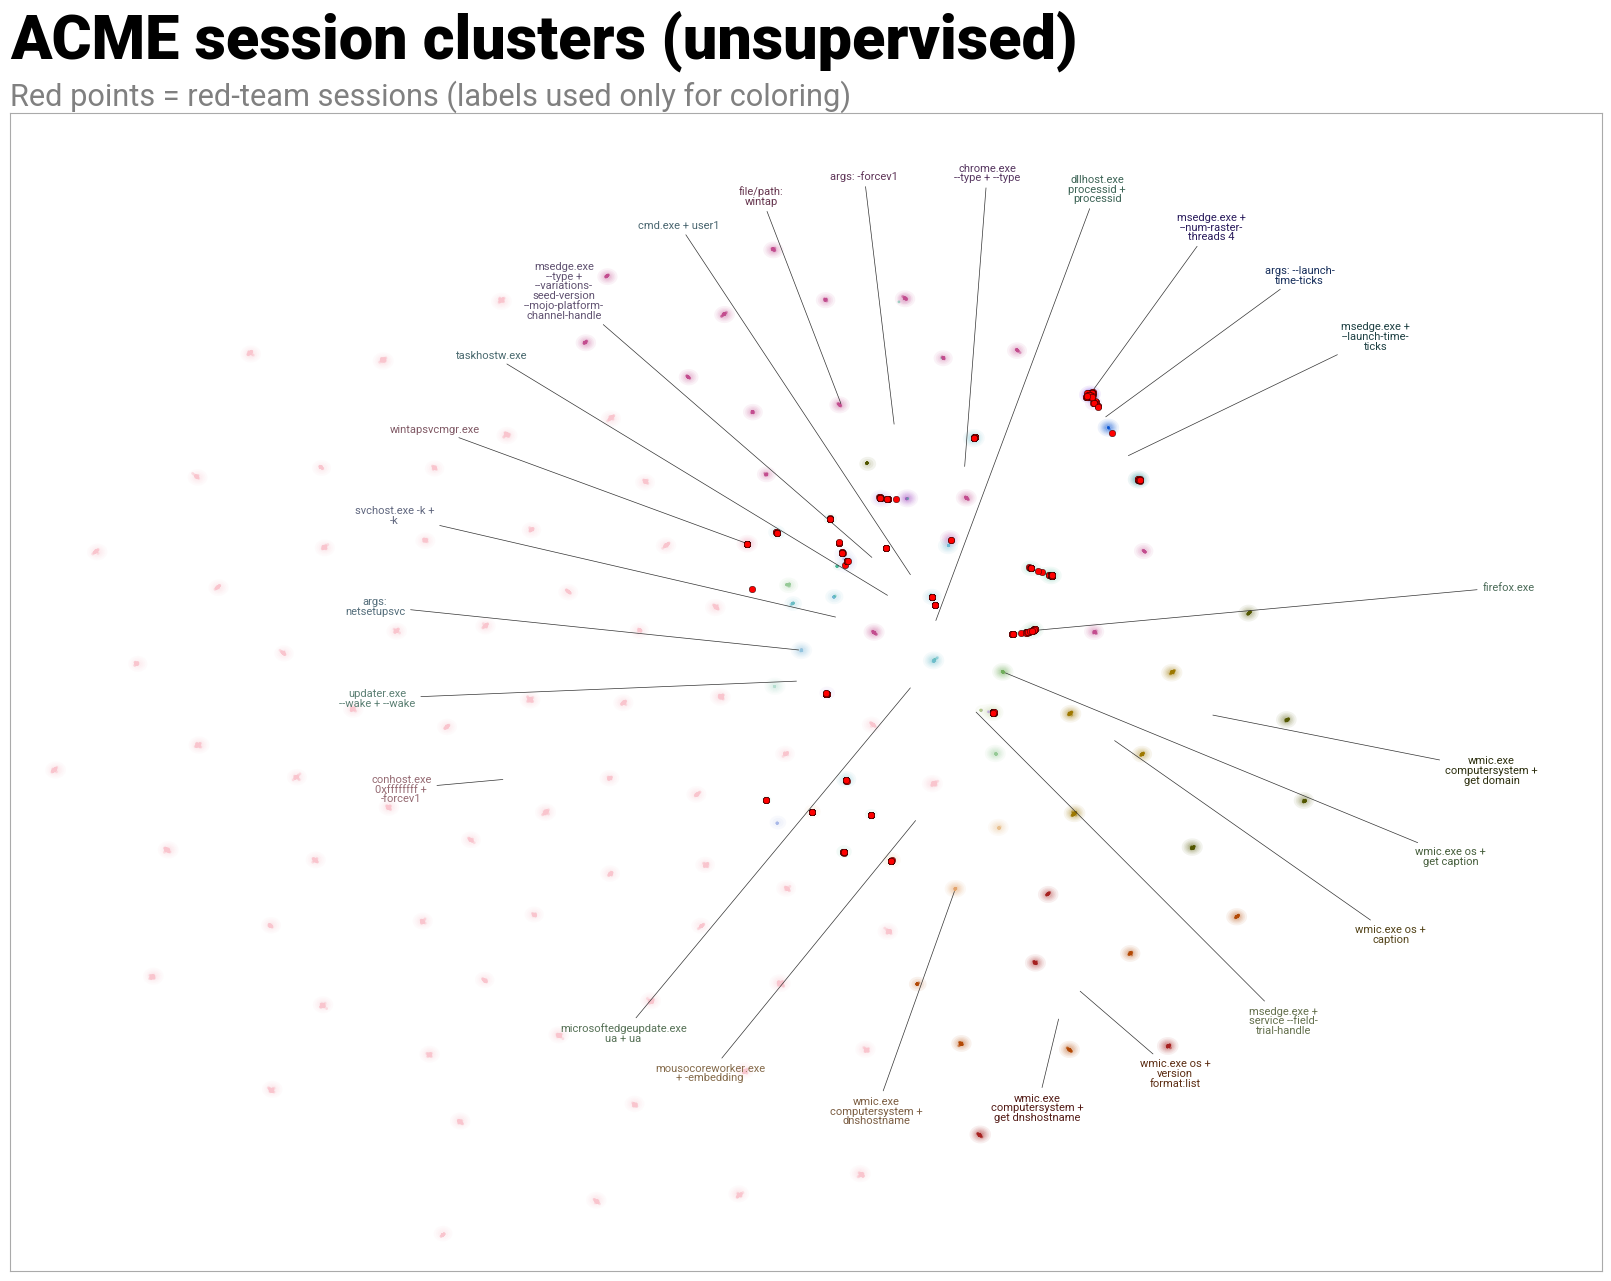

In [26]:
labels_arr = viz["cluster_label"].to_numpy().astype(str)

fig, ax = datamapplot.create_plot(
    coords,
    labels_arr,
    noise_label="Unlabeled",
    title="ACME session clusters (unsupervised)",
    sub_title="Red points = red-team sessions (labels used only for coloring)",
    label_font_size=8,
    point_size=4,
    figsize=(16, 12),
)

# overlay red-team sessions in red on top of the cluster map
ax.scatter(
    coords[red_mask, 0], coords[red_mask, 1],
    s=22, c="red", edgecolors="black", linewidths=0.3, zorder=20, label="red team",
)
fig.savefig("cluster_umap_redteam.png", dpi=150, bbox_inches="tight")
fig

## 4b. Triage view: what the analyst reviews vs. where red-team actually is

This is the clearest read of the effect. Grey = not triaged; blue = the top-N clusters the **unsupervised** strategy would have you review; red = actual red-team sessions. If clustering-first works, the red points fall inside the blue region.

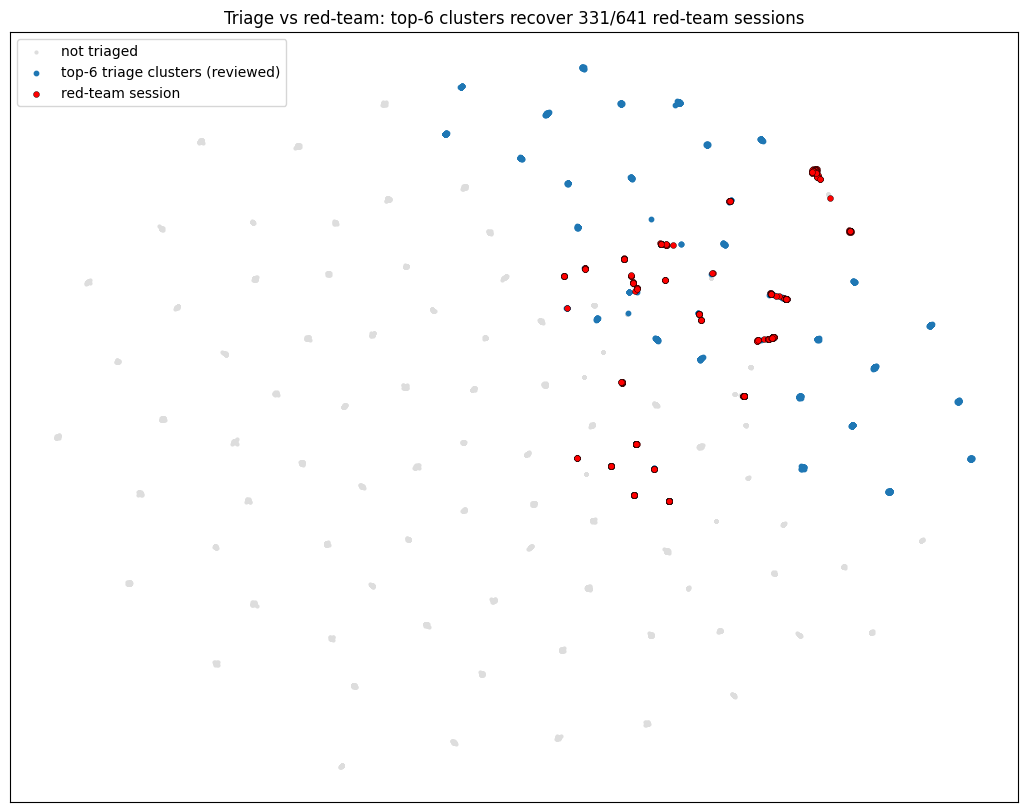

In [17]:
TOP_N_CLUSTERS = 6
top_clusters = set(
    result.cluster_summary.sort_values("score_p95_size_adjusted", ascending=False)["cluster_id"].head(TOP_N_CLUSTERS)
)
is_triage = np.isin(viz["cluster_id"].to_numpy(), list(top_clusters))

fig3, ax3 = plt.subplots(figsize=(13, 10))
ax3.scatter(coords[~is_triage, 0], coords[~is_triage, 1], s=4, c="#dddddd", label="not triaged")
ax3.scatter(coords[is_triage & ~red_mask, 0], coords[is_triage & ~red_mask, 1], s=10, c="#1f77b4", label=f"top-{TOP_N_CLUSTERS} triage clusters (reviewed)")
ax3.scatter(coords[red_mask, 0], coords[red_mask, 1], s=18, c="red", edgecolors="black", linewidths=0.3, zorder=20, label="red-team session")
recovered = int((is_triage & red_mask).sum()); total_red = int(red_mask.sum())
ax3.set_title(f"Triage vs red-team: top-{TOP_N_CLUSTERS} clusters recover {recovered}/{total_red} red-team sessions")
ax3.legend(loc="upper left"); ax3.set_xticks([]); ax3.set_yticks([])
fig3.savefig("cluster_umap_triage.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Plain UMAP colored by red-team (companion view)

A simpler scatter as a sanity check / fallback if datamapplot rendering is heavy.

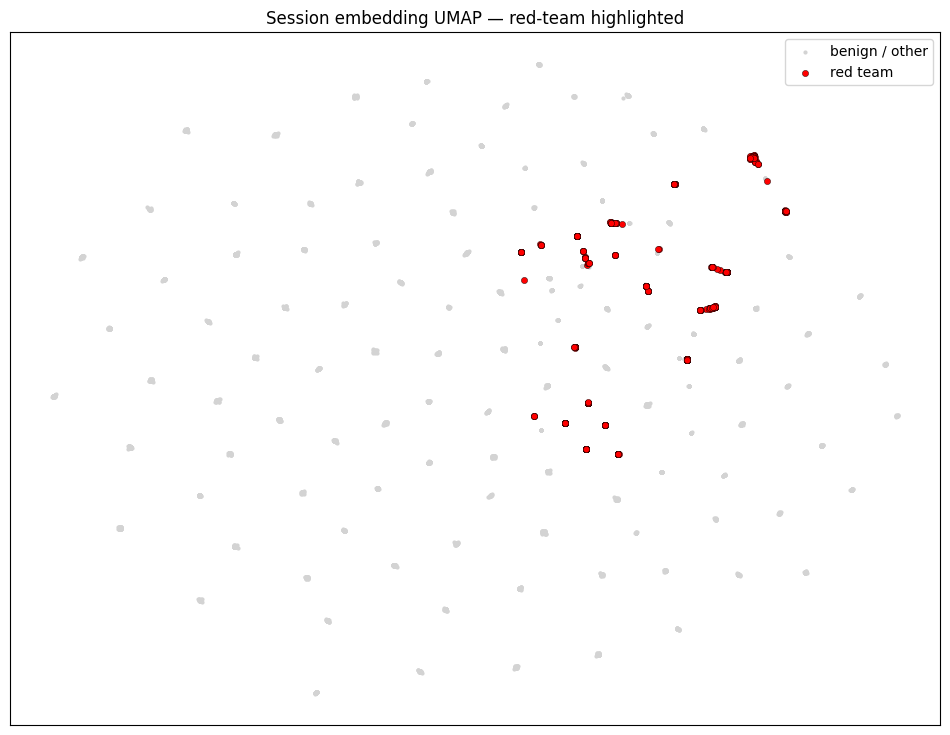

In [18]:
fig2, ax2 = plt.subplots(figsize=(12, 9))
benign_mask = ~red_mask
ax2.scatter(coords[benign_mask, 0], coords[benign_mask, 1], s=4, c="lightgrey", label="benign / other")
ax2.scatter(coords[red_mask, 0], coords[red_mask, 1], s=20, c="red", edgecolors="black", linewidths=0.3, label="red team")
ax2.set_title("Session embedding UMAP — red-team highlighted")
ax2.legend(loc="best")
ax2.set_xticks([]); ax2.set_yticks([])
plt.show()

<InteractiveFigure width=100% height=800>
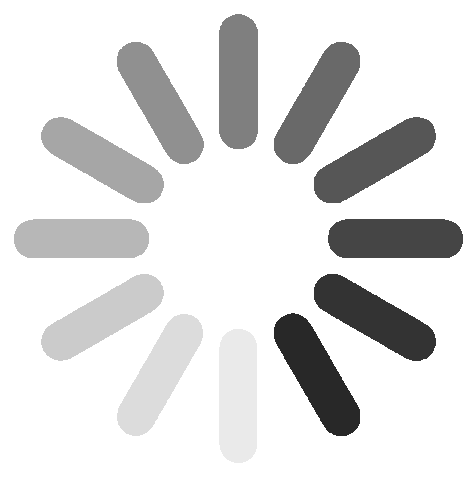

In [19]:
plot = datamapplot.create_interactive_plot(
    coords,
    labels_arr,
    noise_label="Unlabeled",
    title="ACME session clusters (unsupervised)",
    sub_title="Red points = red-team sessions (labels used only for coloring)",
    # label_font_size=8,
    # point_size=4,
    # figsize=(16, 12),
)

plot

## 6. How concentrated is red-team in the top clusters?

The point of clustering-first triage: a few clusters should hold most red-team sessions.

In [10]:
by_cluster = (
    viz.groupby(["cluster_id", "cluster_label"], as_index=False)
    .agg(n_sessions=("red_team", "size"), red_team=("red_team", "sum"))
)
by_cluster["red_team_rate"] = by_cluster["red_team"] / by_cluster["n_sessions"]
by_cluster = by_cluster.sort_values("red_team", ascending=False)
total_red = int(viz["red_team"].sum())
by_cluster["cumulative_recall"] = by_cluster["red_team"].cumsum() / max(total_red, 1)
by_cluster.head(15)

,cluster_id,cluster_label,n_sessions,red_team,red_team_rate,cumulative_recall
18,41,dllhost.exe processid + processid,234,140,0.598291,0.218409
21,45,msedge.exe + --num-raster-threads 4,135,135,1.000000,0.429017
26,63,firefox.exe,70,69,0.985714,0.536661
3,5,msedge.exe + --launch-time-ticks,73,67,0.917808,0.641186
2,3,taskhostw.exe,176,56,0.318182,0.728549
1,2,msedge.exe --type + --variations-seed-version ...,52,46,0.884615,0.800312
12,30,mousocoreworker.exe + -embedding,89,45,0.505618,0.870515
22,49,msedge.exe + service --field-trial-handle,49,38,0.775510,0.929797
10,20,svchost.exe -k + -k,47,15,0.319149,0.953198
23,50,cmd.exe + user1,59,13,0.220339,0.973479


## 7. Essential scoring + metric primitives (experiment here)

`triage_metrics` is the tight surface for trying fixes:

- **3 per-session scoring signals:** `rank_ensemble`, `isolation_forest`, `knn_train_distance`. To try a new scorer, add a column to `result.session_scores` and pass its name.
- **3 label-free cluster-ranking aggregations:** `mean` (current winner), `p95`, `size_adj_p95`.
- **1 core metric:** red-team recall after reviewing top clusters up to a fraction of all *sessions* (real analyst workload — not a cluster count).

The grid below is your experiment table; `mean` currently wins (~0.87 vs ~0.76 at 17%).

In [20]:
from triage_metrics import compare_rankings, plot_recall_curves

grid = compare_rankings(result.session_scores, label_col="red_team", budget=0.17)
grid

,score_col,agg,label,budget,recall,session_review_fraction,clusters_reviewed,lift_vs_baseline
0,knn_train_distance_score,mean,red_team,0.17,0.8502,0.1923,12,4.422
1,isolation_forest_score,p95,red_team,0.17,0.8050,0.1936,14,4.157
2,isolation_forest_score,mean,red_team,0.17,0.6708,0.1735,13,3.867
3,rank_ensemble_score,mean,red_team,0.17,0.6693,0.1725,12,3.879
4,rank_ensemble_score,p95,red_team,0.17,0.6490,0.1785,10,3.635
5,knn_train_distance_score,size_adj_p95,red_team,0.17,0.6303,0.1757,7,3.587
6,isolation_forest_score,size_adj_p95,red_team,0.17,0.6084,0.1736,7,3.505
7,knn_train_distance_score,p95,red_team,0.17,0.5320,0.1721,9,3.092
8,rank_ensemble_score,size_adj_p95,red_team,0.17,0.3058,0.1781,4,1.717


## 8. Recall vs review budget

Each curve is one (signal / aggregation). The thick line is the current default (`rank_ensemble / mean`); the dashed line is the oracle (clusters ranked by true positives). The dotted vertical is the 17% session budget. The gap between the thick line and the dashed oracle is the headroom left in cluster *ranking* — the embeddings already separate the classes.

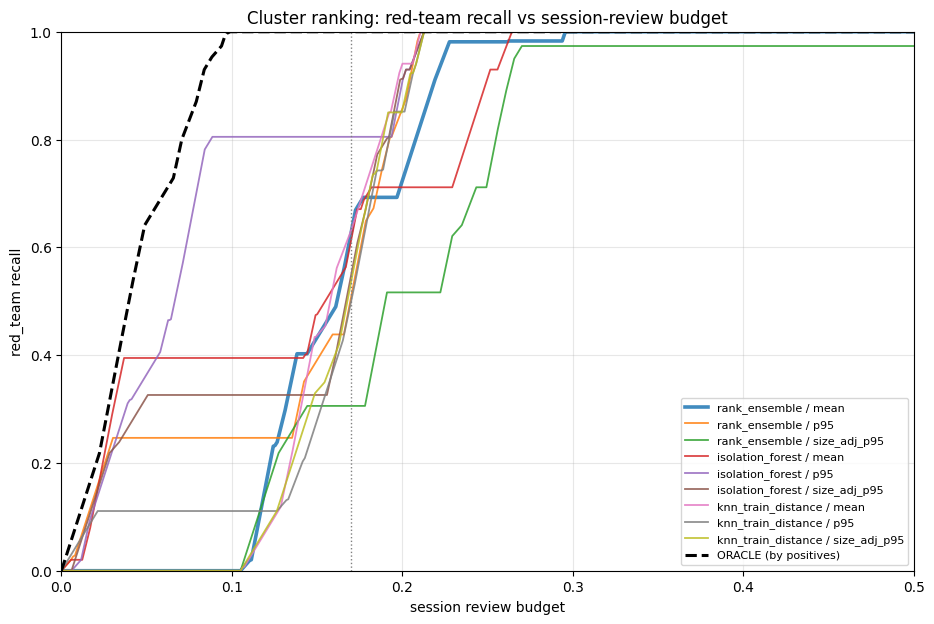

In [21]:
fig4, ax4 = plt.subplots(figsize=(11, 7))
plot_recall_curves(result.session_scores, ax4, label_col="red_team", budget=0.17)
ax4.set_title("Cluster ranking: red-team recall vs session-review budget")
fig4.savefig("cluster_recall_vs_budget.png", dpi=120, bbox_inches="tight")
plt.show()